In [ ]:
# --- plot_revision setup ---
import sys
from pathlib import Path
_HERE = Path.cwd().resolve()
for cand in (_HERE.parent, _HERE / "plot_revision", _HERE):
    if (cand / "paths.py").exists():
        sys.path.insert(0, str(cand))
        break
from paths import (
    REPO, ensure_out_dir,
    RESULT_DIR, RESULT_HUMAN_DIR, RESULT_MOUSE_DIR, RESULT_MULTI_DIR,
    SPC_MULTI_CSV, CLAUDE_CLADE_DIR, TREE_NWK,
    RESULT_RETRIEVAL_DIR, GAP_HUMAN_CSV, GAP_MOUSE_CSV,
    CKPT_ROOT, EPI_EVO2HIC_DIR, PRETRAIN_CKPT_DIR, PRETRAIN_CKPT,
    SR_EVO2HIC_HUMAN_DIR, SEQ2HIC_CKPT,
    HIC_DATA_ROOT, HIC_RAW_DIR, HIC_RAW, DNA_FASTA, MOTIF_MEME,
    EVO2_EMB_HUMAN, EVO2_EMB_MOUSE, TRACKS_GM12878_CHR10_NPY,
    ORCA_MALLPREDS_PTH, ORCA_EXPECTED_NPY,
    MOTIF_STATS_CSV,
    HUMAN_MERGED_CSV, HUMAN_INTER_DIR,
    HIC2TRACK_DIR, HIC2TRACK,
)
OUT_DIR = ensure_out_dir()
# Make `dataset.*` / `config` importable inside notebook cells
from paths import add_repo_to_syspath
add_repo_to_syspath()


In [1]:

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

from importlib import reload
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import seaborn as sns
import matplotlib.patches as patches

from plot_settings import *

from scipy.stats import gaussian_kde, spearmanr
import matplotlib.gridspec as gridspec

import matplotlib as mpl

plt.style.use('seaborn-v0_8-white')



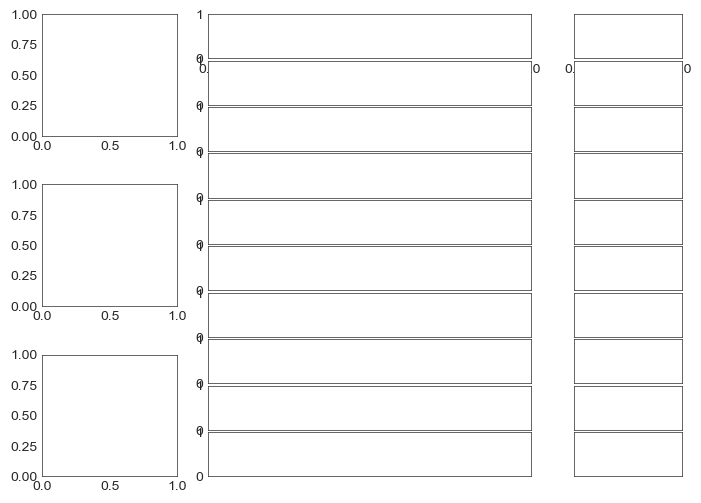

In [2]:
def build_layout(
    figsize=(8.26, 6),
    left_width=1, right_width=3.5,
    right_col_widths=(3, 1),
    wspace_outer=0.1, hspace_left=0.4, hspace_right=0.05
):
    fig = plt.figure(figsize=figsize)

    # 外层：左 1 列 + 右 1 列
    gs_outer = gridspec.GridSpec(
        nrows=1, ncols=2, figure=fig,
        width_ratios=[left_width, right_width],
        wspace=wspace_outer
    )

    # 左侧：3 行 × 1 列
    gs_left = gridspec.GridSpecFromSubplotSpec(
        3, 1, subplot_spec=gs_outer[0, 0], hspace=hspace_left
    )
    ax_left = [fig.add_subplot(gs_left[i, 0]) for i in range(3)]

    # 右侧：10 行 × 2 列（比如：左边“长条”列，右边“短条”列）
    gs_right = gridspec.GridSpecFromSubplotSpec(
        10, 2, subplot_spec=gs_outer[0, 1],
        width_ratios=list(right_col_widths),
        hspace=hspace_right, wspace=0.2
    )
    ax_right_long = []
    ax_right_short = []
    for r in range(10):
        ax_long = fig.add_subplot(gs_right[r, 0])
        ax_short = fig.add_subplot(gs_right[r, 1], sharey=ax_long)  # 同行共享 y 轴（可选）
        ax_right_long.append(ax_long)
        ax_right_short.append(ax_short)

        # 可选：把右侧短条的 ytick 隐掉，让版面更干净
        if r != 0:
            ax_long.tick_params(labelbottom=False)
            ax_short.tick_params(labelbottom=False)
        ax_short.tick_params(labelleft=False)

    axes = {
        "left": ax_left,                    # 长度 3 的列表
        "right_long": ax_right_long,        # 长度 10 的列表
        "right_short": ax_right_short       # 长度 10 的列表
    }
    return fig, axes

# ==== 示范 ====
fig, axes = build_layout()

# 全局调样式（可选）
for ax in axes["left"] + axes["right_long"] + axes["right_short"]:
    # ax.axis('off')
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)


In [3]:
import matplotlib as mpl
plt.rcParams.update({'font.size': 8})
print("xtick.labelsize:", mpl.rcParams['xtick.labelsize'])
print("ytick.labelsize:", mpl.rcParams['ytick.labelsize'])
print("axes.labelsize:", mpl.rcParams['axes.labelsize'])
print("axes.titlesize:", mpl.rcParams['axes.titlesize'])
print("legend.fontsize:", mpl.rcParams['legend.fontsize'])


xtick.labelsize: medium
ytick.labelsize: medium
axes.labelsize: medium
axes.titlesize: large
legend.fontsize: medium


# 1. results

In [4]:
all_results={
    'GM12878':{
        'Evo 2'   : [0.5065071772686310, 0.684883661639269, 0.4723215174678410, 0.5532150994412120, 0.743785894435787],
        'HiC-only'    : [0.7555425418310320, 0.5478374086262150, 0.7821511771949210, 0.4827902697229720, 0.7226159535967270],
        'No-pretrain' : [0.7784518082491350, 0.8396883667647270, 0.7914340970166780, 0.6812159868426440, 0.835766542633833],
        'Evo2HiC'     : [0.8134805480351930, 0.8427020226598800, 0.814738257592789, 0.7328604239910880, 0.850397408254733],
    },
    'H1ESC':{
        'Evo 2'   : [0.7852085670872220, 0.6675326625366060, 0.6091666666305720, 0.7523833759033170, 0.89368730072835],
        'HiC-only'    : [0.6574804610574850, 0.5262463362749490, 0.6217840004270640, 0.45868114259819700, 0.6667056955209520],
        'No-pretrain' : [0.79720312988487, 0.85112130134229, 0.6923879607117040, 0.7343641687560060, 0.9033671177972810],
        'Evo2HiC'     : [0.8306446664514490, 0.85127456816043, 0.7331594121051890, 0.772733778719945, 0.9149756313583790],
    },
    'K562':{
        'Evo 2'   : [0.6925672990585390, 0.6820523672011140, 0.5791933798486720, 0.5183731507972170, 0.7949491712541050],
        'HiC-only'    : [0.6640371883143740, 0.481084598483613, 0.540558423028512, 0.323333008100551, 0.6248553189286910],
        'No-pretrain' : [0.6988484766499840, 0.80588169121063, 0.5426438520089620, 0.247491977592968, 0.791788284335979],
        'Evo2HiC'     : [0.7387326520042270, 0.8201187899079630, 0.546606620659416, 0.28189418793198200, 0.8108013840119270],
    },
}

In [5]:
improvements_Evo2HiC_vs_Evo2 = []
improvements_Evo2HiC_vs_HiC_only = []
for cell in ['GM12878', 'H1ESC']:
    for i in range(5):
        imp0 = all_results[cell]['Evo2HiC'][i]/all_results[cell]['Evo 2'][i]-1
        improvements_Evo2HiC_vs_Evo2.append(imp0)
        imp1 = all_results[cell]['Evo2HiC'][i]/all_results[cell]['HiC-only'][i]-1
        improvements_Evo2HiC_vs_HiC_only.append(imp1)
print(improvements_Evo2HiC_vs_Evo2)
print(np.mean(improvements_Evo2HiC_vs_Evo2))
print(np.mean(improvements_Evo2HiC_vs_HiC_only))

[0.606059271305756, 0.23043090361196938, 0.7249653624943355, 0.32472961192008487, 0.1433362942434102, 0.057865007169719096, 0.2752553035017189, 0.20354486262429106, 0.02704791661856576, 0.023820782294522003]
0.26170553157843723
0.3468583667782127


In [6]:
statistic_tests = {
    'GM12878':[
        ('Evo2HiC', 'HiC-only',  0.0 ),
        ('Evo2HiC', 'Evo 2',  0.0 ),
        ('Evo2HiC', 'HiC-only',  0.0 ),
        ('Evo2HiC', 'Evo 2',  0.0 ),
        ('Evo2HiC', 'HiC-only',  0.0 )
    ],
    'H1ESC':[
        ('Evo2HiC', 'Evo 2',  0.0 ),
        ('Evo2HiC', 'Evo 2',  0.0 ),
        ('Evo2HiC', 'HiC-only',  0.0 ),
        ('Evo2HiC', 'Evo 2',  4.945934438446685e-61 ),
        ('Evo2HiC', 'Evo 2',  0.0 )
    ],
    'K562':[
        ('Evo2HiC', 'Evo 2',  1.0779747694546158e-266 ),
        ('Evo2HiC', 'Evo 2',  0.0 ),
        ('Evo2HiC', 'Evo 2',  1.0 ),
        ('Evo2HiC', 'Evo 2',  1.0 ),
        ('Evo2HiC', 'Evo 2',  7.439063095499756e-77 )
    ]
}

# 2. radar plot (deprecated)

In [7]:
# # Data
# tracks = {
#     'DNase': 'DNase.bw', 
#     'CTCF': 'CTCF.bw', 
#     'H3K27ac': 'H3K27ac.bw',
#     'H3K27me3': 'H3K27me3.bw',
#     'H3K4me3': 'H3K4me3.bw'
# }

# labels = list(tracks.keys())

# # Prepare angle for each axis
# b = 0.1 * np.pi
# angles = np.linspace(b, b+2 * np.pi, len(labels), endpoint=False).tolist()
# angles += angles[:1]

# labels += [labels[0]]  # to close the loop

# # Plot
# fig, axs = plt.subplots(1, 2, figsize=(12, 7), subplot_kw=dict(polar=True))

# for ax, (result_name, results) in zip(axs, all_results.items()):
#     for k,v in results.items():
#         result = results[k]+results[k][:1]
#         result = np.array(result)
#         ax.plot(angles, result, label=k, linewidth=2)
#         ax.fill(angles, result, alpha=0.1)

#     # Hide default tick labels
#     ax.set_xticks(angles[:-1])
#     ax.set_xticklabels([])

#     ax.set_yticklabels([])
#     top = 1.0
#     ax.set_ylim(bottom=0, top=top)
#     # Place custom radial tick labels *inside*
#     yticks = [0.2, 0.4, 0.6, 0.8, 1.0]
#     for y in yticks:
#         ax.text(np.radians(90), y-0.04,  # 90 degrees is top
#                 f"{y:.1f}",
#                 ha='center', va='center',
#                 fontsize=8, color='gray')
    
#     # Manually add rotated labels
#     for angle, label in zip(angles[:-1], labels[:-1]):
#         angle_deg = np.degrees(angle) + 90
#         radius = top + 0.05  # slightly beyond outer edge

#         alignment = 'center'
#         angle_deg += 180

#         ax.text(angle, radius, label,
#                 horizontalalignment=alignment,
#                 verticalalignment='center',
#                 rotation=angle_deg,
#                 rotation_mode='anchor',
#                 fontsize=10)

#     ax.set_title(result_name, pad=30)

# # Legend
# axs[-1].legend(loc='upper left', bbox_to_anchor=(1.0, 1.0))

# plt.tight_layout()
# plt.savefig(str(OUT_DIR / 'track_result_radar.pdf'))
# plt.show()

# 3. barplot

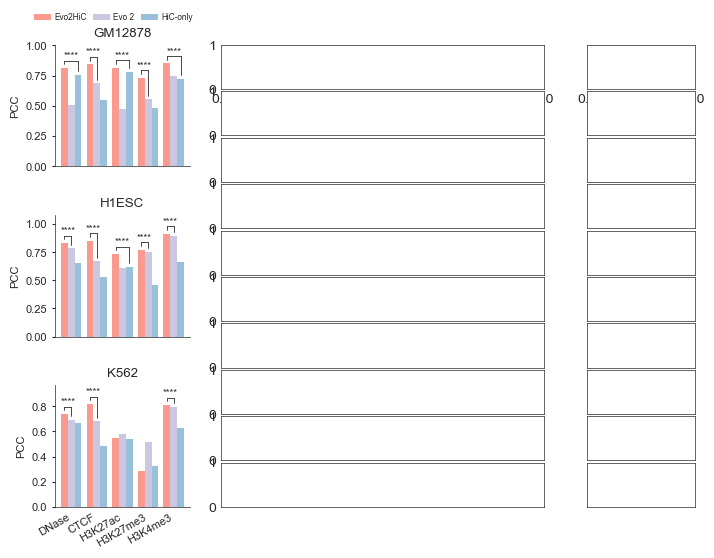

In [8]:
from plot_utils import _p_to_stars, _annotate_pair_asymmetric
# Data
tracks = {
    'DNase': 'DNase.bw', 
    'CTCF': 'CTCF.bw', 
    'H3K27ac': 'H3K27ac.bw',
    'H3K27me3': 'H3K27me3.bw',
    'H3K4me3': 'H3K4me3.bw'
}
labels = list(tracks.keys())

methods = ['Evo2HiC', 'Evo 2', 'HiC-only']

# 方法 -> 索引
meth2idx = {m:i for i, m in enumerate(methods)}

for ax, (result_name, results) in zip(axes['left'], all_results.items()):
    ax.clear()
    ax.set_aspect('auto')

    # --- 画柱子 ---
    n_m = len(methods)
    width = 0.8 / n_m
    x = np.arange(len(labels))

    for i, m in enumerate(methods):
        ax.bar(
            x + i*width, results[m],
            width=width,
            label=m,
            color=colors[i % len(colors)],
            alpha=0.8
        )

    ax.set_ylabel("PCC")
    ax.set_title(result_name)
    ax.tick_params(axis='x', which='both', length=0)
    ax.tick_params(axis='y', which='both', length=2)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.set_xticks([])

    # --- 预留顶部空间，避免星号/支架被裁掉 ---
    max_val = np.nanmax([np.asarray(results[m]) for m in methods])
    ymin, ymax = 0.0, float(max_val * 1.18)  # 适当抬高 18%
    ax.set_ylim(ymin, ymax)

    # --- 根据 statistic_tests 画“非对称支架 + 星号” ---
    tests = statistic_tests.get(result_name, [])
    # 如果 tests 数量和 tracks 数量一致：逐 track 取一个；否则也能按 min 长度走
    for t_idx, tup in enumerate(tests[:len(labels)]):
        m1, m2, p = tup
        # 忽略 None 或非法方法名
        if (m1 not in meth2idx) or (m2 not in meth2idx):
            continue

        # 左右柱子的 x 位置
        x_left  = x[t_idx] + meth2idx[m1] * width
        x_right = x[t_idx] + meth2idx[m2] * width

        # 左右柱子的“cap”高度（就是柱顶）
        y_cap_left  = float(results[m1][t_idx])
        y_cap_right = float(results[m2][t_idx])

        # p -> 星号
        stars = _p_to_stars(p if p is not None else 1.0)

        if stars == 'n.s.': continue

        # 画支架（你提供的辅助函数，已支持非对称脚）
        _annotate_pair_asymmetric(
            ax,
            x_left=x_left, x_right=x_right,
            y_cap_left=y_cap_left, y_cap_right=y_cap_right,
            pad_frac=0.03,   # 比默认稍小，避免顶到上沿
            arm_frac=0.03,
            text=stars,
            lw=0.5, fontsize=7
        )

# 只在第三个子图上显示 x 轴类别标签
axes['left'][2].set_xticks(x + width*(len(methods)-1)/2)
axes['left'][2].set_xticklabels(labels, rotation=30, ha='right')

# Legend 维持你原来的做法
pos = axes['left'][0].get_position()
handles, leg_labels = axes['left'][0].get_legend_handles_labels()
if hasattr(fig, "legend_") and fig.legend_ is not None:
    fig.legend_.remove()
fig.legend(
    handles, leg_labels,
    loc='upper left',
    bbox_to_anchor=(pos.x0-0.03, pos.y1 + 0.06),
    ncol=len(leg_labels),
    frameon=False,
    fontsize=6,
    handletextpad=0.4,
    columnspacing=0.8,
    borderaxespad=0.1
)
fig

# 4. Epi vis

In [9]:
import sys
# sys.path.append('../') handled by bootstrap
import numpy as np
import matplotlib.pyplot as plt
from dataset.track_loader import Track_Loader
from config import tracks

arrays = [
    np.load(str(EPI_EVO2HIC_DIR / 'GM12878' / '9.npy')),
    np.load(str(EPI_EVO2HIC_DIR / 'H1ESC' / '9.npy')),
    np.load(str(EPI_EVO2HIC_DIR / 'K562' / '9.npy')),
]

tls = [
    Track_Loader(str(HIC2TRACK('GM12878')), 2000),
    Track_Loader(str(HIC2TRACK('H1ESC')), 2000),
    Track_Loader(str(HIC2TRACK('K562')), 2000)
]

gts = []
for tl in tls:
    gts.append(tl.get(9, 0, (tl.chr_lens['chr9']//2000+1)*2000, 0))

track_names = list(tracks.keys())


../data/hic2track/GM12878
0.0364 0.07343012021471802
0.03516 0.058822779373849575
0.03607 0.105951909994905
0.02351 0.02145021099161991
0.04712 0.13544065389145613
../data/hic2track/H1ESC
0.02719 0.05062306103814994
0.03262 0.04458704097539131
0.03014 0.02216416410242311
0.03146 0.07153794095320824
0.0371 0.08985833671621105
../data/hic2track/K562
0.0345 0.09881654622137444
0.03458 0.0594217816687648
0.03537 0.04801165554653757
0.02376 0.019239994650150895
0.0415 0.11127198028830755


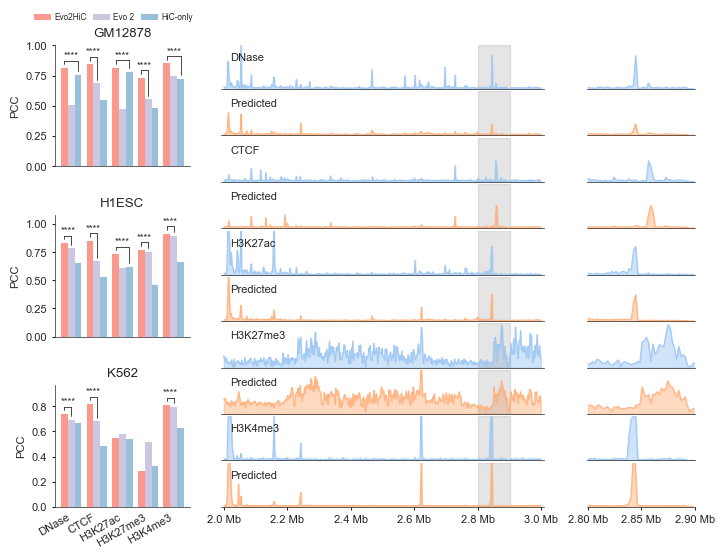

In [10]:
from matplotlib.ticker import NullFormatter

L, R = 1000, 1500

zoom_L, zoom_R = 1400, 1450

axes_main = axes['right_long']
axes_zoom = axes['right_short']

for i in range(10):
    axes_main[i].clear()
    axes_zoom[i].clear()
    axes_main[i].margins(x=0.01)
    axes_zoom[i].margins(x=0.01)

for i in range(5):
    axes_main[i*2].plot(range(L, R), gts[0][i, L:R], color=sns.color_palette("pastel")[0], linewidth=0.8)
    axes_main[i*2].fill_between(range(L, R), gts[0][i, L:R], color=sns.color_palette("pastel")[0], alpha=0.5)

    axes_main[i*2+1].plot(range(L, R), arrays[0][i, L:R], color=sns.color_palette("pastel")[1], linewidth=0.8)
    axes_main[i*2+1].fill_between(range(L, R), arrays[0][i, L:R], color=sns.color_palette("pastel")[1], alpha=0.5)

    axes_main[i*2].text(
        0.03, 0.6, track_names[i],
        fontsize=8, ha='left', va='bottom',
        transform=axes_main[i*2].transAxes, zorder=5
    )
    axes_main[i*2+1].text(
        0.03, 0.6, 'Predicted',
        fontsize=8, ha='left', va='bottom',
        transform=axes_main[i*2+1].transAxes, zorder=5
    )

    axes_zoom[i*2].plot(range(zoom_L, zoom_R), gts[0][i, zoom_L:zoom_R], color=sns.color_palette("pastel")[0], linewidth=0.8)
    axes_zoom[i*2].fill_between(range(zoom_L, zoom_R), gts[0][i, zoom_L:zoom_R], color=sns.color_palette("pastel")[0], alpha=0.5)

    axes_zoom[i*2+1].plot(range(zoom_L, zoom_R), arrays[0][i, zoom_L:zoom_R], color=sns.color_palette("pastel")[1], linewidth=0.8)
    axes_zoom[i*2+1].fill_between(range(zoom_L, zoom_R), arrays[0][i, zoom_L:zoom_R], color=sns.color_palette("pastel")[1], alpha=0.5)

    if i != 3:
        axes_main[i*2].set_ylim(0, 1)
        axes_main[i*2+1].set_ylim(0, 1)
        axes_zoom[i*2].set_ylim(0, 1)
        axes_zoom[i*2+1].set_ylim(0, 1)
    else:
        axes_main[i*2].set_ylim(0, 0.1)
        axes_main[i*2+1].set_ylim(0, 0.1)
        axes_zoom[i*2].set_ylim(0, 0.1)
        axes_zoom[i*2+1].set_ylim(0, 0.1)

    for ax in [axes_main[i*2], axes_main[i*2+1]]:
        ax.axvspan(zoom_L, zoom_R, color='gray', alpha=0.2)

for ax in axes_main + axes_zoom:
    ax.set_yticks([])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)

for i, ax in enumerate(axes_zoom):
    if i != 9:
        ax.xaxis.set_major_formatter(NullFormatter())
        ax.xaxis.offsetText.set_visible(False)

for i, ax in enumerate(axes_main):
    if i != 9:
        ax.xaxis.set_major_formatter(NullFormatter())
        ax.xaxis.offsetText.set_visible(False)

# 最后一行的 x 轴加上刻度
axes_main[-1].set_xticks(range(L, R+1, (R-L)//5))
axes_main[-1].set_xticklabels([f"{x/500:.1f} Mb" for x in range(L, R+1, (R-L)//5)])
axes_zoom[-1].set_xticks(range(zoom_L, zoom_R+1, (zoom_R-zoom_L)//2))
axes_zoom[-1].set_xticklabels([f"{x/500:.2f} Mb" for x in range(zoom_L, zoom_R+1, (zoom_R-zoom_L)//2)])

# 关键：重新开启最后一行的 x 轴标签显示
axes_main[-1].tick_params(axis='x', which='both', labelbottom=True, length=2)
axes_zoom[-1].tick_params(axis='x', which='both', labelbottom=True, length=2)
axes_main[-1].xaxis.offsetText.set_visible(True)
axes_zoom[-1].xaxis.offsetText.set_visible(True)

fig

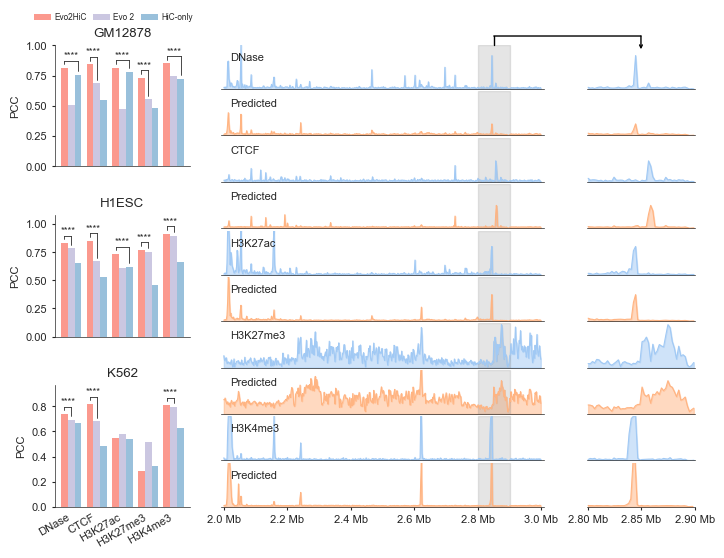

In [11]:
from matplotlib.patches import ConnectionPatch
from matplotlib import transforms as mtransforms

# ===== 参数可按需微调 =====
ax_main_top = axes_main[0]   # 选你要加支架的那一行主图
ax_zoom_top = axes_zoom[0]   # 对应要指向的缩放图
x_mid = (zoom_L + zoom_R) / 2

y_top_line = 1.2   # 顶部横线/竖线到达的高度（轴分数坐标，>1 表示轴外上方）
lw = 1.0

# 竖线①（主图）：从灰框顶端(轴分数 y=1.0)到 y_top_line
# x 用数据坐标（精确卡在灰框中点），y 用轴分数坐标（贴着轴顶向上）
blend_main = mtransforms.blended_transform_factory(ax_main_top.transData, ax_main_top.transAxes)
ax_main_top.plot([x_mid, x_mid], [1.0, y_top_line], transform=blend_main,
                 color='black', lw=lw, clip_on=False, zorder=20)

# 横线：连接主图顶点(x_mid, y_top_line) → 缩放图顶点(0.5, y_top_line)
hline = ConnectionPatch(
    xyA=(x_mid, y_top_line),   coordsA=blend_main,              # 主图：x=数据、y=轴分数
    xyB=(0.5,  y_top_line),    coordsB=ax_zoom_top.transAxes,   # 缩放图：轴分数(居中)
    arrowstyle='-', lw=lw, shrinkA=0.0, shrinkB=0.0, clip_on=False
)
fig.add_artist(hline)

# 竖线②（缩放图，带箭头）：从 y_top_line 向下指到 zoom 轴的中间
down_arrow = ConnectionPatch(
    xyA=(0.5, y_top_line),   coordsA=ax_zoom_top.transAxes,     # 起点：缩放图上方
    xyB=(0.5, 0.9), coordsB=ax_zoom_top.transAxes,   # 终点：缩放图中间
    arrowstyle='->', lw=lw, mutation_scale=5,
    shrinkA=0.0, shrinkB=0.0, clip_on=False
)
fig.add_artist(down_arrow)
fig


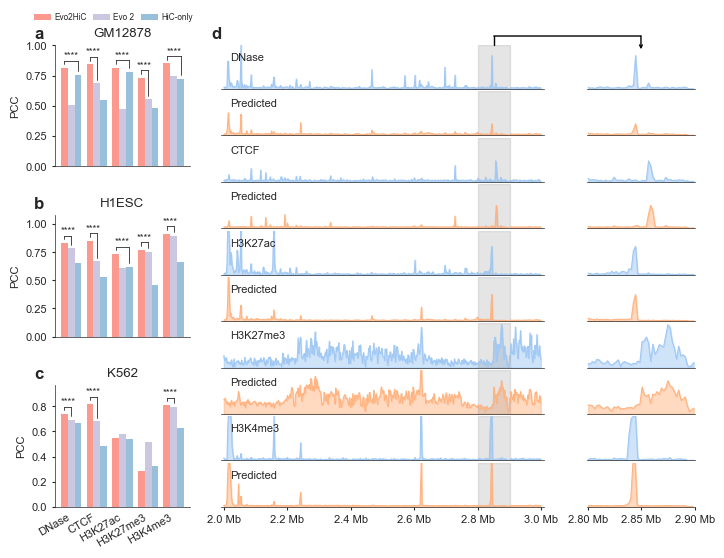

In [12]:
labels = ['a', 'b', 'c']

for ax, label in zip(axes['left'], labels):
    ax.text(
        -0.15, 1.15, f'{label}',           # 相对位置：左上角内一点
        transform=ax.transAxes, 
        fontsize=12,
        fontname='Arial',               # 字体
        fontweight='bold',                  # 粗体 (Nature风格)
        ha='left', va='top'                 # 对齐方式
    )

axes["right_long"][0].text(
        -0.03, 1.4, f'd',           # 相对位置：左上角内一点
        transform=axes["right_long"][0].transAxes, 
        fontsize=12,
        fontname='Arial',               # 字体
        fontweight='bold',                  # 粗体 (Nature风格)
        ha='left', va='top'                 # 对齐方式
    )

fig

In [13]:
fig.savefig(str(OUT_DIR / 'Fig3_Epi.pdf'), dpi=300, transparent=True)